In [1]:
import numpy as np
import pandas as pd
import pvlib
import yaml
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent
zone = "centro_sud"
year = 2020

weather = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "weather" / zone / f"weather_{year}.csv",
    index_col=0,
    parse_dates=True,
)
weather.head()

weather = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "weather" / zone / f"weather_{year}.csv",
    index_col=0,
    parse_dates=True,
)
weather.index = pd.to_datetime(weather.index, utc=True).tz_convert("Europe/Rome")
weather.head()

,temp_c,ghi_wm2,bhi_wm2,pressure_pa,wind_speed_ms
valid_time,,,,,
2020-01-01 00:00:00+01:00,4.798675,0.0,0.0,100717.984,2.741750
2020-01-01 00:15:00+01:00,4.770386,0.0,0.0,100718.590,2.746909
2020-01-01 00:30:00+01:00,4.742096,0.0,0.0,100719.200,2.752067
2020-01-01 00:45:00+01:00,4.713806,0.0,0.0,100719.810,2.757226
2020-01-01 01:00:00+01:00,4.685516,0.0,0.0,100720.420,2.762384


In [3]:
with open(PROJECT_ROOT / "config.yaml") as f:
    config = yaml.safe_load(f)

cities = config["zones"][zone]["cities"]
lat = np.mean([c["lat"] for c in cities])
lon = np.mean([c["lon"] for c in cities])
lat, lon

(np.float64(42.08), np.float64(13.342500000000001))

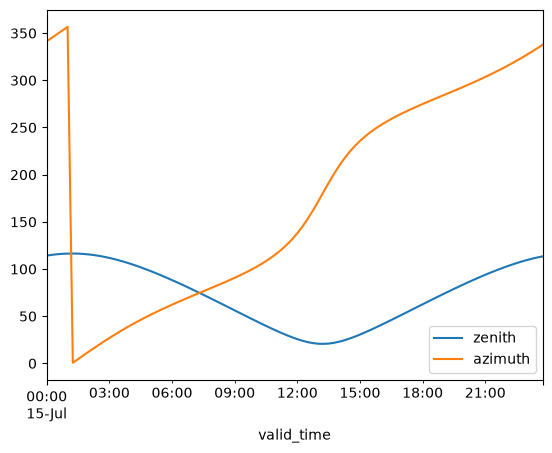

In [4]:
solpos = pvlib.solarposition.get_solarposition(
    time=weather.index,
    latitude=lat,
    longitude=lon,
)
solpos[["zenith", "azimuth"]].loc[f"{year}-07-15"].plot()
plt.show()

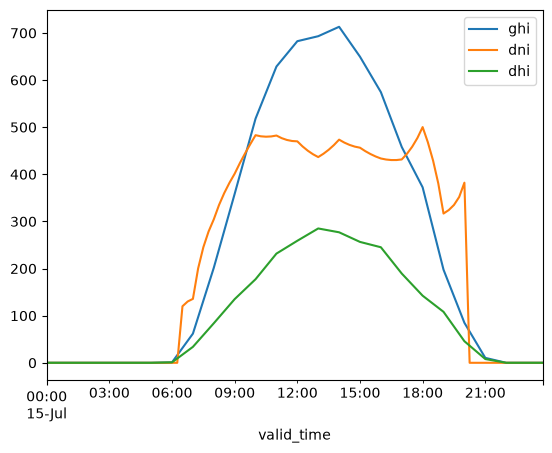

In [5]:
zenith_rad = np.radians(solpos["zenith"])
cos_zenith = np.cos(zenith_rad)

bhi = weather["bhi_wm2"]
ghi = weather["ghi_wm2"]

dni = bhi / cos_zenith
dni = dni.where(solpos["zenith"] < 85, 0.0).clip(upper=1000)
dhi = (ghi - bhi).clip(lower=0)

irradiance = pd.DataFrame({"ghi": ghi, "dni": dni, "dhi": dhi}, index=weather.index)
irradiance.loc[f"{year}-07-15"].plot()
plt.show()

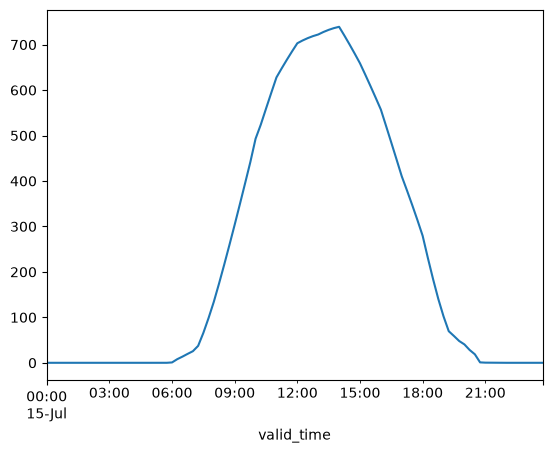

In [6]:
dni_extra = pvlib.irradiance.get_extra_radiation(weather.index)
airmass = pvlib.atmosphere.get_relative_airmass(solpos["zenith"])

poa = pvlib.irradiance.get_total_irradiance(
    surface_tilt=lat,
    surface_azimuth=180,
    solar_zenith=solpos["zenith"],
    solar_azimuth=solpos["azimuth"],
    dni=dni,
    ghi=ghi,
    dhi=dhi,
    dni_extra=dni_extra,
    airmass=airmass,
    model="perez",
)
poa["poa_global"].loc[f"{year}-07-15"].plot()
plt.show()

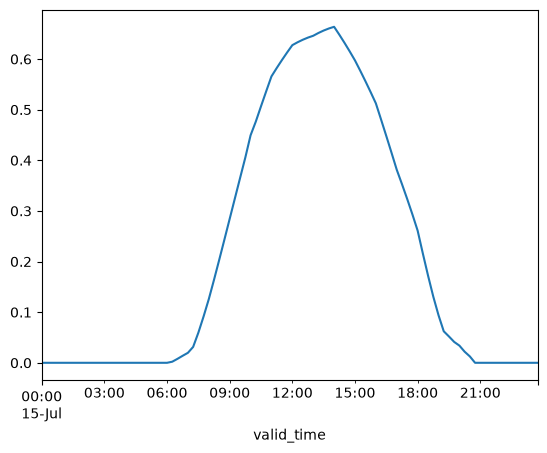

np.float64(0.20593442047597993)

In [7]:
temp_cell = pvlib.temperature.noct_sam(
    poa_global=poa["poa_global"],
    temp_air=weather["temp_c"],
    wind_speed=weather["wind_speed_ms"],
    noct=45,
    module_efficiency=0.19,
)

pdc = pvlib.pvsystem.pvwatts_dc(
    effective_irradiance=poa["poa_global"],
    temp_cell=temp_cell,
    pdc0=1,
    gamma_pdc=-0.0047,
)

ac_cf = pvlib.inverter.pvwatts(pdc, pdc0=1, eta_inv_nom=0.96)
ac_cf.loc[f"{year}-07-15"].plot()
plt.show()

ac_cf.mean()

In [8]:
from windpowerlib import WindTurbine, power_output

turbine = WindTurbine(turbine_type="E-101/3050", hub_height=100)

def wind_capacity_factor(speed):
    power = power_output.power_curve(
        wind_speed=speed,
        power_curve_wind_speeds=turbine.power_curve["wind_speed"],
        power_curve_values=turbine.power_curve["value"],
    )
    return power / turbine.nominal_power

city_cf = wind_capacity_factor(weather["wind_speed_ms"])
city_cf.mean()

np.float64(0.09198189987286498)

In [9]:
import xarray as xr

wind_ds = xr.open_dataset(PROJECT_ROOT / "data" / "raw" / "weather" / "era5_centro_sud_wind_bisaccia.nc")
wind_ds

<xarray.Dataset> Size: 9MB
Dimensions:     (valid_time: 289272)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2MB 1991-01-01 ... 2023-12-31T23:...
    latitude    float64 8B ...
    longitude   float64 8B ...
Data variables:
    u100        (valid_time) float32 1MB ...
    v100        (valid_time) float32 1MB ...
    t2m         (valid_time) float32 1MB ...
    sp          (valid_time) float32 1MB ...
    ssrd        (valid_time) float32 1MB ...
    fdir        (valid_time) float32 1MB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

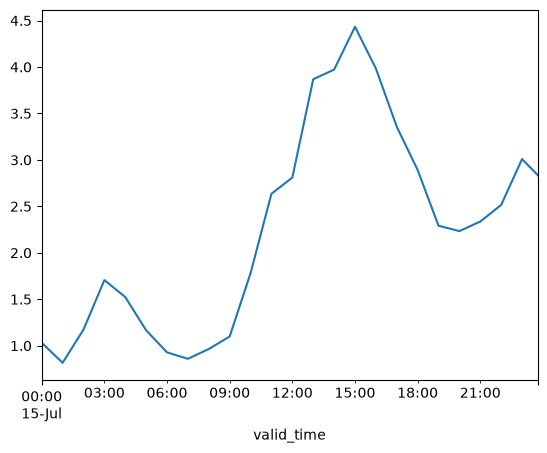

In [10]:
wind_df = wind_ds.to_dataframe().reset_index()
time_col = "valid_time" if "valid_time" in wind_df.columns else "time"
wind_df = wind_df.set_index(time_col)

wind_speed = np.sqrt(wind_df["u100"]**2 + wind_df["v100"]**2)
wind_speed = wind_speed.resample("15min").asfreq().interpolate(method="time")
wind_speed.index = wind_speed.index.tz_localize("UTC").tz_convert("Europe/Rome")

wind_speed.loc[f"{year}-07-15"].plot()
plt.show()

In [11]:
site_cf = wind_capacity_factor(wind_speed)

print("city-average (config cities) CF:", city_cf.mean())
print("Bisaccia wind-farm-site CF:", site_cf.mean())

city-average (config cities) CF: 0.09198189987286498
Bisaccia wind-farm-site CF: 0.12825877523217177
